In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.model_selection import train_test_split

### Class Definition

In [2]:
dtype = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class FNN(nn.Module):
    def __init__(self, layers, activation=nn.ReLU):
        """
        layers : list of ints, e.g. [2, 50, 50, 1] for a 2-input 2-hidden 1-output net.
        """
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = activation()

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return self.layers[-1](x)
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)
    
    def loss_fn(self, pred, target):
        return torch.mean((pred - target) ** 2)
    
    def train_model(self, x_train, y_train, epochs=1000, lr=1e-3, track_loss=False, x_val=None, y_val=None, lr_change=None):
        optimizer = optim.Adam(self.parameters(), lr=lr)  # Using Adam optimizer. parameters is hereded from nn.Module
        if track_loss:
            loss_history = []
            val_loss = []

        for epoch in trange(epochs, desc="Training Epoch: "):
            # Check if is time to change learning rate
            if lr_change is not None and epoch == lr_change[0]:
                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr_change[1]

            self.train()  # Set the model to training mode
            optimizer.zero_grad()
            pred = self.forward(x_train)
            loss = self.loss_fn(pred, y_train)
            if track_loss:
                pred_val = self.forward(x_val)
                val_loss.append(self.loss_fn(pred_val, y_val).item())
                loss_history.append(loss.item())
            loss.backward()  # Compute gradients
            optimizer.step()  # Update the parameters based on the computed gradients

        return loss_history, val_loss if track_loss else None
    
    def mesh_location(self):
        # I want to make a visual rapresentation of where the shallow NN is putting the mesh nodes after training. Therefore I need to extract weights and biases
        weights = []
        biases = []
        for layer in self.layers:
            weights.append(layer.weight.data.cpu().numpy())
            biases.append(layer.bias.data.cpu().numpy())
        return weights, biases

### Data Genration

In [3]:
def generate_data(n_samples):
    x = np.random.uniform(-1, 1, n_samples)  # Uniform in [-1, 1]
    # Target function
    y = 1/(1 + 50 * x**2)
    return torch.tensor(x, dtype=dtype, device=device).unsqueeze(1), torch.tensor(y, dtype=dtype, device=device).unsqueeze(1)

x_gen, y_gen = generate_data(10000)
x_train, x_test, y_train, y_test = train_test_split(x_gen, y_gen, test_size=0.2, random_state=42)

In [ ]:
# Model creation and training
model = FNN([1, 128, 128, 1], activation=nn.Tanh).to(device)  # Model definition
loss_history, val_loss = model.train_model(x_train, y_train, epochs=5000, lr=1e-3, track_loss=True, x_val=x_test, y_val=y_test, lr_change=[1200, 1e-4])  # Train the model

Training Epoch: 100%|██████████| 5000/5000 [00:43<00:00, 114.62it/s]


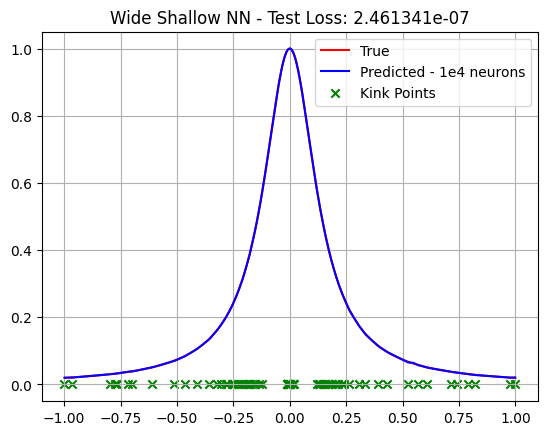

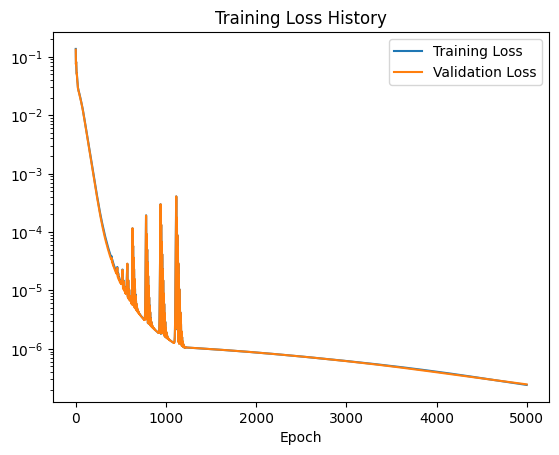

In [5]:
# Evaluate on test set
y_pred = model.predict(x_test)
test_loss = model.loss_fn(y_pred, y_test)
mask = np.argsort(x_test.cpu().numpy().flatten()) # flatten diminuishes the dimension of the tensor, making it easier to sort and plot

# Extract the mesh kink points
weights, biases = model.mesh_location()
kink_points = -biases[0] / weights[0].flatten()  # Without the [0] we would get a list, as also the output layer counts as a layer.
kink_points = kink_points[(kink_points >= -1) & (kink_points <= 1)]  # Filter kink points to be within the input range

plt.plot(x_test.cpu()[mask], y_test.cpu()[mask], 'r', label='True')
plt.plot(x_test.cpu()[mask], y_pred.cpu()[mask], 'b', label='Predicted - 1e4 neurons')
plt.scatter(kink_points, np.zeros_like(kink_points), label='Kink Points', marker='x', color='green')
plt.legend()
plt.grid(True)
plt.title(f'Wide Shallow NN - Test Loss: {test_loss.item():.6e}')
plt.show()

plt.figure()
plt.semilogy(loss_history, label='Training Loss')
plt.semilogy(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.title('Training Loss History')
plt.legend()